In [1]:
import os
import json
import pandas as pd
from bs4 import BeautifulSoup

In [ ]:
#some random shitm

In [2]:
test_path = r"D:\personal projects\r6-cheater-detector\cheater_data\YDDADSIOAN.-.json"

In [3]:

with open(test_path, "r", encoding="utf-8") as file:
    content = file.read().strip()
    
    # Parse HTML structure and extract JSON inside <pre> tag
    soup = BeautifulSoup(content, "html.parser")
    pre_tag = soup.find("pre")
    if not pre_tag:
        print(f"No JSON data found")

    
    json_data = json.loads(pre_tag.text)  # Load JSON

In [4]:
def parse_json(data):
    # Extract top-level information
    parsed_data = {
        "platformUserId": data["data"].get("platformInfo", {}).get("platformUserId", np.nan),
        "isVerified": data["data"].get("userInfo", {}).get("isVerified", np.nan),
        "pageviews": data["data"].get("userInfo", {}).get("pageviews", np.nan),
        "xpTier": data["data"].get("userInfo", {}).get("xpTier", np.nan),
        "isSuspicious": data["data"].get("userInfo", {}).get("isSuspicious", np.nan),
        "nameChanges": len(data["data"].get("metadata", {}).get("nameChanges", [])),
        "currentSeason": data["data"].get("metadata", {}).get("currentSeason", np.nan),
        "clearanceLevel": data["data"].get("metadata", {}).get("clearanceLevel", np.nan),
        "isOverwolfAppUser": data["data"].get("metadata", {}).get("isOverwolfAppUser", np.nan),
        "battlepassLevel": data["data"].get("metadata", {}).get("battlepassLevel", np.nan),
    }
    
    # Initialize dictionary for storing season data
    num_seasons = 37  # Considering 37 seasons
    season_data = {}
    
    for season in range(1, num_seasons + 1):
        for gamemode in ["Quick Match", "Ranked", "Standard", "Event", "Arcade"]:  # You can extend with more gamemodes
            prefix = f"season_{season}_{gamemode.lower().replace(' ', '')}_"
            season_data.update({
                prefix + "matchesplayed": np.nan,
                prefix + "matcheswon": np.nan,
                prefix + "matcheslost": np.nan,
                prefix + "kills": np.nan,
                prefix + "deaths": np.nan,
                prefix + "kdRatio": np.nan,
                prefix + "mmr": np.nan,
                prefix + "maxMmr": np.nan,
            })
    
    # Parse segments
    for segment in data["data"].get("segments", []):
        if segment.get("type") == "season":
            season_number = segment.get("attributes", {}).get("season")
            gamemode = segment.get("metadata", {}).get("gamemodeName", "Unknown")
            
            if season_number is not None and season_number <= num_seasons:
                prefix = f"season_{season_number}_{gamemode.lower().replace(' ', '')}_"
                stats = segment.get("stats", {})
                
                season_data[prefix + "matchesplayed"] = stats.get("matchesPlayed", {}).get("value", np.nan)
                season_data[prefix + "matcheswon"] = stats.get("matchesWon", {}).get("value", np.nan)
                season_data[prefix + "matcheslost"] = stats.get("matchesLost", {}).get("value", np.nan)
                season_data[prefix + "kills"] = stats.get("kills", {}).get("value", np.nan)
                season_data[prefix + "deaths"] = stats.get("deaths", {}).get("value", np.nan)
                season_data[prefix + "kdRatio"] = stats.get("kdRatio", {}).get("value", np.nan)
                season_data[prefix + "mmr"] = stats.get("mmr", {}).get("value", np.nan)
                season_data[prefix + "maxMmr"] = stats.get("maxMmr", {}).get("value", np.nan)
    
    # Parse overview section
    overview_data = {}
    for segment in data["data"].get("segments", []):
        if segment.get("type") == "overview":
            stats = segment.get("stats", {})
            for key, value in stats.items():
                feature_name = f"overview_{key.lower()}"
                overview_data[feature_name] = value.get("value", np.nan)
    
    # Parse gamemode section
    gamemode_data = {}
    for segment in data["data"].get("segments", []):
        if segment.get("type") == "gamemode":
            gamemode_name = segment.get("metadata", {}).get("gamemodeName", "Unknown").lower().replace(" ", "")
            stats = segment.get("stats", {})
            for key, value in stats.items():
                feature_name = f"gamemode_{gamemode_name}_{key.lower()}"
                gamemode_data[feature_name] = value.get("value", np.nan)
    
    # Merge all extracted data
    parsed_data.update(season_data)
    parsed_data.update(overview_data)
    parsed_data.update(gamemode_data)
    
    return parsed_data

In [5]:
import numpy as np

In [6]:
def flatten_json(nested_json, parent_key='', sep='_'):
    """
    Recursively flattens a nested JSON object.
    """
    items = []
    for key, value in nested_json.items():
        new_key = f"{parent_key}{sep}{key}" if parent_key else key  # Generate new key
        
        if isinstance(value, dict):
            items.extend(flatten_json(value, new_key, sep=sep).items())  # Recursive flattening
        
        elif isinstance(value, list):
            if all(isinstance(i, dict) for i in value):  # Handle list of dictionaries
                for idx, item in enumerate(value):
                    items.extend(flatten_json(item, f"{new_key}_{idx}", sep=sep).items())
            else:
                items.append((new_key, value))  # Directly append if it's a list of values
        
        else:
            items.append((new_key, value))  # Base case: primitive value

    return dict(items)

# Define the directory containing JSON files
directory = r"D:\personal projects\r6-cheater-detector\cheater_data"  # Change this to your actual directory

# List to store extracted data
data_list = []

# Loop through all files in the directory
for filename in os.listdir(directory):
    if filename.endswith(".json") or filename.endswith(".html"):  # Ensure it's a JSON-like file
        file_path = os.path.join(directory, filename)

        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                content = file.read().strip()
                
                # Use BeautifulSoup to extract JSON from HTML
                soup = BeautifulSoup(content, "html.parser")
                pre_tag = soup.find("pre")
                
                if not pre_tag or not pre_tag.text:
                    print(f"Skipping invalid file: {filename}")
                    continue
                
                json_data = json.loads(pre_tag.text)
                
                # Flatten the JSON dynamically
                flattened_data = parse_json(json_data)
                data_list.append(flattened_data)
        
        except json.JSONDecodeError as e:
            print(f"JSON Decode Error in {filename}: {e}")
        except Exception as e:
            print(f"Unexpected Error in {filename}: {e}")

# Convert to Pandas DataFrame
cheater_df = pd.DataFrame(data_list)



Unexpected Error in acidsquid72.json: 'data'
Skipping invalid file: Adblockerlol..json
Skipping invalid file: AKA_HipHop.json
Unexpected Error in AlexisTexas2ez.json: 'data'
Unexpected Error in Asdnawyusdbuawb.json: 'data'
Skipping invalid file: B0t.0Bama.json
Unexpected Error in baeiiq0.json: 'data'
Skipping invalid file: BEAUL0....LEGlT.json
Skipping invalid file: Beaulo_Smurf1.json
Skipping invalid file: BeetlePimp4Pres.json
Unexpected Error in blueheets.json: 'data'
Skipping invalid file: boomay59.json
Unexpected Error in BubbaDeLyon.json: 'data'
Unexpected Error in BUREKWARE.json: 'data'
Unexpected Error in CarryDai.-.json: 'data'
Unexpected Error in CutyStwi.json: 'data'
Skipping invalid file: danny1.0.json
Skipping invalid file: deepdarki587.json
Skipping invalid file: del200403110008003.json
Unexpected Error in Doc_Holiday.-.json: 'data'
Unexpected Error in DonutBoy1854.json: 'data'
Skipping invalid file: EkremAbi22.json
Unexpected Error in ErBdyGOniteNite.json: 'data'
Skipping

In [7]:
cheater_df

,platformUserId,isVerified,pageviews,xpTier,isSuspicious,nameChanges,currentSeason,clearanceLevel,isOverwolfAppUser,battlepassLevel,...,gamemode_event_killspermatch,gamemode_event_winpercentage,season_19_newcomer_matchesplayed,season_19_newcomer_matcheswon,season_19_newcomer_matcheslost,season_19_newcomer_kills,season_19_newcomer_deaths,season_19_newcomer_kdRatio,season_19_newcomer_mmr,season_19_newcomer_maxMmr
0,bea4b579-77a8-4618-964e-9ca6f97b9889,False,0,NaN,None,1,34,25.0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3d0c4c2d-889d-4a8c-a7cb-c443a4384322,False,0,NaN,None,0,34,135.0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a3f91a93-a79f-4280-ae9e-20ab5fb07253,False,273,NaN,None,1,34,68.0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,740afdbf-82eb-43f7-b670-f177102cc86e,False,0,NaN,None,0,34,42.0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,62299f22-65d5-4e7f-a403-f8eb937612e8,False,6552,NaN,None,0,34,83.0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1895,b956987a-a6f0-4262-befb-4f37088ff8c7,False,236,NaN,None,1,34,72.0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1896,884b1185-d224-43ba-bf28-3dee66584238,False,169,NaN,None,1,34,95.0,False,NaN,...,5.88,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1897,4119cf9a-f4d7-49ff-8759-d47964473dbb,False,195,NaN,None,2,34,75.0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1898,02d73094-6acf-417f-a40c-3e618b7c5f6c,False,0,NaN,None,0,34,45.0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
import matplotlib.pyplot as plt

(array([1.219e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 1.130e+02, 0.000e+00, 2.360e+02, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 2.500e+01,
        0.000e+00, 1.600e+01, 0.000e+00, 1.850e+02, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 4.000e+00, 0.000e+00, 6.000e+00, 0.000e+00,
        3.200e+01, 0.000e+00, 3.900e+01, 0.000e+00, 0.000e+00, 0.000e+00,
        2.000e+00, 0.000e+00, 0.000e+00, 6.000e+00, 0.000e+00, 1.400e+01,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
        0.000e+00, 2.000e+00]),
 array([1541.  , 1541.92, 1542.84, 1543.76, 1544.68, 1545.6 , 1546.52,
        1547.44, 1548.36, 1549.28, 1550.2 , 1551.12, 1552.04, 1552.96,
        1553.88, 1554.8 , 1555.72, 1556.64, 1557.56, 1558.48, 1559.4 ,
        1560.32, 1561.24, 1562.16, 1563.08, 1564.  , 1564.92, 1565.84,
        1566.76, 1567.68, 1568.6 , 1569.52, 1570.44, 1571.36, 1572.28,
        1573.2 , 1574

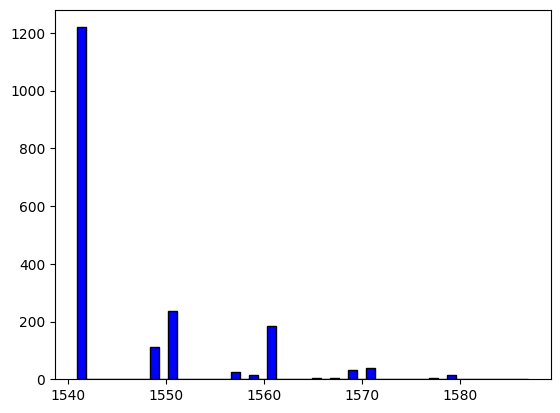

In [9]:
lengths = []

for d in data_list:
    lengths.append(len(d))

plt.hist(lengths, bins=50, edgecolor='black', color='blue')

In [9]:
data_list2 = [d for d in data_list if len(d)>50]

In [10]:
common_keys = set(data_list2[0]).intersection(*data_list2[1:])

In [11]:
len(common_keys)

564

In [ ]:
for key in common_keys:
    print(key)

In [13]:
common_data = {key: [d.get(key) for d in data_list2] for key in common_keys}

In [14]:
df_common = pd.DataFrame(common_data, index=[f'Dict_{i+1}' for i in range(len(data_list2))])

In [15]:
df_common

,data_metadata_lastUpdated,data_segments_0_stats_playstyleDefenderTrapper_value,data_segments_1_stats_deaths_displayCategory,data_segments_0_stats_playstyleDefenderIntelProvider_displayValue,data_segments_1_stats_matchesWon_percentile,data_segments_0_stats_playstyleAttackerIntelProvider_displayType,data_segments_0_stats_matchesWon_value,data_segments_0_stats_attackerEnemyKillsOutObj_category,data_segments_1_stats_matchesAbandoned_rank,data_segments_0_stats_timePlayed_value,...,data_segments_0_stats_playstyleAttackerEntryFragger_rank,data_segments_0_stats_playstyleDefenderDebuffer_value,data_segments_1_stats_winPercentage_displayType,data_segments_0_stats_playstyleAttackerRoamClearer_displayValue,data_segments_0_stats_playstyleAttackerEntryFragger_displayValue,data_segments_1_stats_killsPerMatch_value,data_segments_0_stats_teamKills_displayValue,data_segments_0_stats_playstyleAttackerIntelProvider_metadata_color,data_segments_0_stats_matchesAbandoned_displayType,data_segments_1_stats_kdRatio_displayValue
Dict_1,None,0,Combat,0,None,Number,31,attacker,None,0,...,None,0,NumberPercentage,0,0,6.83,0,#FFD700,Number,3.90
Dict_2,None,23,Combat,42,None,Number,73,attacker,None,212365,...,None,40,NumberPercentage,38,49,0.00,0,#FFD700,Number,0.00
Dict_3,None,0,Combat,0,None,Number,73,attacker,None,0,...,None,0,NumberPercentage,0,0,10.00,0,#FFD700,Number,3.93
Dict_4,None,2,Combat,240,None,Number,64,attacker,None,0,...,None,23,NumberPercentage,0,95,7.92,0,#FFD700,Number,3.81
Dict_5,None,0,Combat,0,None,Number,79,attacker,None,0,...,None,0,NumberPercentage,0,0,67.00,0,#FFD700,Number,67.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Dict_1897,None,7,Combat,9,None,Number,198,attacker,None,0,...,None,21,NumberPercentage,1,27,7.91,0,#FFD700,Number,1.95
Dict_1898,None,213,Combat,177,None,Number,286,attacker,None,645533,...,None,210,NumberPercentage,99,332,7.11,0,#FFD700,Number,1.90
Dict_1899,None,0,Combat,0,None,Number,173,attacker,None,0,...,None,0,NumberPercentage,0,0,6.08,0,#FFD700,Number,1.53
Dict_1900,None,0,Combat,0,None,Number,20,attacker,None,0,...,None,0,NumberPercentage,0,0,0.00,0,#FFD700,Number,0.00


In [16]:
# Remove columns where all values are the same
df_unique_columns = df_common.loc[:, (df_common.nunique() > 1)]

In [ ]:
for col in df_unique_columns.columns:
    print(col)

In [18]:
df_unique_columns

,data_segments_0_stats_playstyleDefenderTrapper_value,data_segments_0_stats_playstyleDefenderIntelProvider_displayValue,data_segments_0_stats_matchesWon_value,data_segments_0_stats_timePlayed_value,data_segments_0_stats_killsPerMatch_displayValue,data_segments_0_stats_defenderTeamKillsInObj_value,data_segments_0_stats_matchesAbandoned_value,data_segments_0_stats_defenderRoundsWon_displayValue,data_platformInfo_platformUserHandle,data_metadata_uplayUserId,...,data_segments_1_stats_kdRatio_value,data_segments_0_stats_defenderEnemyKillsInObj_value,data_segments_0_stats_attackerTeamKillsOutObj_value,data_userInfo_pageviews,data_segments_0_stats_playstyleDefenderDebuffer_value,data_segments_0_stats_playstyleAttackerRoamClearer_displayValue,data_segments_0_stats_playstyleAttackerEntryFragger_displayValue,data_segments_1_stats_killsPerMatch_value,data_segments_0_stats_teamKills_displayValue,data_segments_1_stats_kdRatio_displayValue
Dict_1,0,0,31,0,8.92,0,0,56,A.__.-_._.-.._-,bea4b579-77a8-4618-964e-9ca6f97b9889,...,3.90,0,0,0,0,0,0,6.83,0,3.90
Dict_2,23,42,73,212365,3.72,0,1,"2,078",A1VapeNation101,3d0c4c2d-889d-4a8c-a7cb-c443a4384322,...,0.00,5,0,0,40,38,49,0.00,0,0.00
Dict_3,0,0,73,0,7.02,0,0,167,A3CP,a3f91a93-a79f-4280-ae9e-20ab5fb07253,...,3.93,0,0,273,0,0,0,10.00,0,3.93
Dict_4,2,240,64,0,7.75,0,0,152,AbeDuLeckEier,740afdbf-82eb-43f7-b670-f177102cc86e,...,3.81,0,0,0,23,0,95,7.92,0,3.81
Dict_5,0,0,79,0,12.16,0,0,207,AboutToSneez,62299f22-65d5-4e7f-a403-f8eb937612e8,...,67.00,0,0,6552,0,0,0,67.00,0,67.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Dict_1897,7,9,198,0,5.29,0,0,409,ZxL.Pano,b956987a-a6f0-4262-befb-4f37088ff8c7,...,1.95,0,0,236,21,1,27,7.91,0,1.95
Dict_1898,213,177,286,645533,5.06,0,55,825,ZxusBD,884b1185-d224-43ba-bf28-3dee66584238,...,1.90,0,0,169,210,99,332,7.11,0,1.90
Dict_1899,0,0,173,0,5.99,0,0,530,ZyklonB.eSSL,4119cf9a-f4d7-49ff-8759-d47964473dbb,...,1.53,0,0,195,0,0,0,6.08,0,1.53
Dict_1900,0,0,20,0,10.09,0,0,57,ZyTxYT,02d73094-6acf-417f-a40c-3e618b7c5f6c,...,0.00,0,0,0,0,0,0,0.00,0,0.00


In [ ]:
# Loop through DataFrame columns
for col in df_unique_columns.columns:
    series = df_unique_columns[col]

    # Check if the column is numeric and NOT boolean
    if pd.api.types.is_numeric_dtype(series) and not pd.api.types.is_bool_dtype(series):
        plt.figure(figsize=(8, 4))
        plt.hist(series.dropna(), edgecolor='black', bins=50, color='blue')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

In [ ]:
# Loop through DataFrame columns
for col in df_unique_columns.columns:
    series = df_unique_columns[col]

    # Check if the column is numeric and NOT boolean
    if not pd.api.types.is_numeric_dtype(series):
        print(col)

In [24]:
# Loop through DataFrame columns
for col in df_unique_columns.columns:
    series = df_unique_columns[col]

    # Check if the column is numeric and NOT boolean
    if pd.api.types.is_bool_dtype(series):
        print(col)

data_userInfo_isVerified
data_metadata_isOverwolfAppUser


In [26]:
true_cols = [col for col in df_unique_columns.columns if pd.api.types.is_numeric_dtype(df_unique_columns[col]) and not pd.api.types.is_bool_dtype(df_unique_columns[col])]

In [28]:
len(true_cols)

66

In [19]:
type(df_unique_columns['data_platformInfo_platformUserHandle'][0])

C:\Users\anant\AppData\Local\Temp\ipykernel_14824\564262880.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  type(df_unique_columns['data_platformInfo_platformUserHandle'][0])


str

(0.0, 3.0)

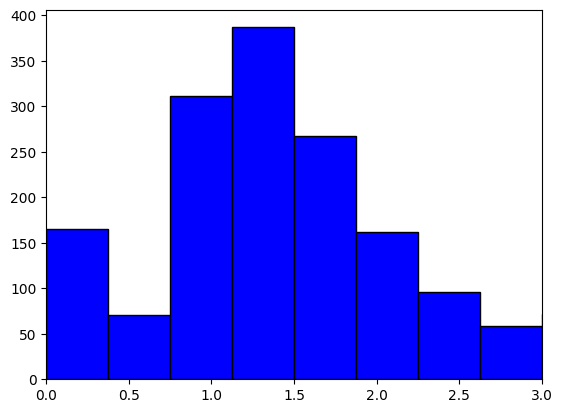

In [ ]:
plt.hist(df_unique_columns['data_segments_1_stats_kdRatio_value'], bins=200, edgecolor='black', color='blue')``
plt.xlim(0,3)

(0.0, 3.0)

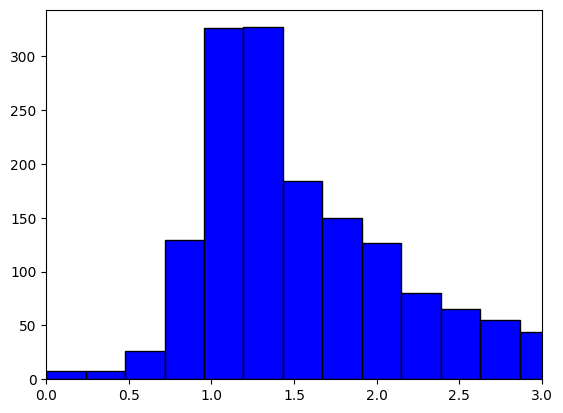

In [48]:
plt.hist(df_unique_columns['data_segments_0_stats_kdRatio_value'], bins=200, edgecolor='black', color='blue')
plt.xlim(0,3)

(0.0, 100.0)

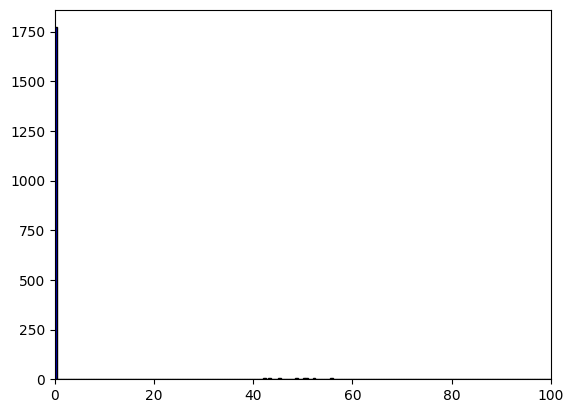

In [53]:
plt.hist(df_unique_columns['data_segments_0_stats_headshotPercentage_value'], bins=200, edgecolor='black', color='blue')
plt.xlim(0,100)

In [14]:
cheater_df2 = cheater_df.dropna(axis=1)

In [15]:
cheater_df2.head()

""
0
1
2
3
4


In [9]:
cheater_df.describe()

,data_platformInfo_additionalParameters,data_userInfo_userId,data_userInfo_customAvatarUrl,data_userInfo_customHeroUrl,data_userInfo_customAvatarFrame,data_userInfo_customAvatarFrameInfo,data_userInfo_premiumDuration,data_userInfo_pageviews,data_userInfo_xpTier,data_userInfo_isSuspicious,...,data_segments_33_stats_rankPoints_category,data_segments_33_stats_rankPoints_description,data_segments_33_stats_rankPoints_metadata_topRankPosition,data_segments_33_stats_rankPoints_value,data_segments_33_stats_maxRankPoints_rank,data_segments_33_stats_maxRankPoints_percentile,data_segments_33_stats_maxRankPoints_displayCategory,data_segments_33_stats_maxRankPoints_category,data_segments_33_stats_maxRankPoints_description,data_segments_33_stats_maxRankPoints_value
count,0.0,2.000000e+01,0.0,0.0,0.0,0.0,0.0,1901.000000,2.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
mean,NaN,4.746287e+06,NaN,NaN,NaN,NaN,NaN,298.327196,1.0,NaN,...,NaN,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0
std,NaN,2.170028e+06,NaN,NaN,NaN,NaN,NaN,1256.218824,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,8.037200e+05,NaN,NaN,NaN,NaN,NaN,0.000000,1.0,NaN,...,NaN,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0
25%,NaN,3.602700e+06,NaN,NaN,NaN,NaN,NaN,0.000000,1.0,NaN,...,NaN,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0
50%,NaN,4.309825e+06,NaN,NaN,NaN,NaN,NaN,132.000000,1.0,NaN,...,NaN,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0
75%,NaN,5.532249e+06,NaN,NaN,NaN,NaN,NaN,305.000000,1.0,NaN,...,NaN,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0
max,NaN,1.012953e+07,NaN,NaN,NaN,NaN,NaN,34884.000000,1.0,NaN,...,NaN,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0


In [10]:
cheater_df.iloc[:, 100:110]


,data_segments_0_stats_attackerRoundsWon_value,data_segments_0_stats_attackerRoundsWon_displayValue,data_segments_0_stats_attackerRoundsWon_displayType,data_segments_0_stats_attackerTeamKillsInObj_rank,data_segments_0_stats_attackerTeamKillsInObj_percentile,data_segments_0_stats_attackerTeamKillsInObj_displayName,data_segments_0_stats_attackerTeamKillsInObj_displayCategory,data_segments_0_stats_attackerTeamKillsInObj_category,data_segments_0_stats_attackerTeamKillsInObj_description,data_segments_0_stats_attackerTeamKillsInObj_value
0,61.0,61,Number,NaN,NaN,Attacker Team Kills In Obj,Attacker,attacker,NaN,0.0
1,1998.0,"1,998",Number,NaN,NaN,Attacker Team Kills In Obj,Attacker,attacker,NaN,0.0
2,158.0,158,Number,NaN,NaN,Attacker Team Kills In Obj,Attacker,attacker,NaN,0.0
3,179.0,179,Number,NaN,NaN,Attacker Team Kills In Obj,Attacker,attacker,NaN,0.0
4,169.0,169,Number,NaN,NaN,Attacker Team Kills In Obj,Attacker,attacker,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...
1954,390.0,390,Number,NaN,NaN,Attacker Team Kills In Obj,Attacker,attacker,NaN,0.0
1955,706.0,706,Number,NaN,NaN,Attacker Team Kills In Obj,Attacker,attacker,NaN,0.0
1956,511.0,511,Number,NaN,NaN,Attacker Team Kills In Obj,Attacker,attacker,NaN,0.0
1957,46.0,46,Number,NaN,NaN,Attacker Team Kills In Obj,Attacker,attacker,NaN,0.0


In [28]:

threshold = 0.9 * len(cheater_df) 

cheater_df_cleaned = cheater_df.dropna(axis=1, thresh=threshold)

In [29]:
cheater_df_cleaned

,data_platformInfo_platformSlug,data_platformInfo_platformUserId,data_platformInfo_platformUserHandle,data_platformInfo_platformUserIdentifier,data_platformInfo_avatarUrl,data_userInfo_isPremium,data_userInfo_isVerified,data_userInfo_isInfluencer,data_userInfo_isPartner,data_userInfo_pageviews,...,data_segments_1_stats_killsPerMatch_value,data_segments_1_stats_killsPerMatch_displayValue,data_segments_1_stats_killsPerMatch_displayType,data_segments_1_stats_winPercentage_displayName,data_segments_1_stats_winPercentage_displayCategory,data_segments_1_stats_winPercentage_category,data_segments_1_stats_winPercentage_value,data_segments_1_stats_winPercentage_displayValue,data_segments_1_stats_winPercentage_displayType,data_expiryDate
0,ubi,bea4b579-77a8-4618-964e-9ca6f97b9889,A.__.-_._.-.._-,A.__.-_._.-.._-,https://ubisoft-avatars.akamaized.net/bea4b579...,False,False,False,False,0.0,...,6.83,6.83,NumberPrecision2,Win %,Game,game,66.67,66.7%,NumberPercentage,2024-08-28T02:57:44.8219479+00:00
1,ubi,3d0c4c2d-889d-4a8c-a7cb-c443a4384322,A1VapeNation101,A1VapeNation101,https://ubisoft-avatars.akamaized.net/3d0c4c2d...,False,False,False,False,0.0,...,0.00,0.00,NumberPrecision2,Win %,Game,game,0.00,0.0%,NumberPercentage,2024-08-25T23:11:25.3041714+00:00
2,ubi,a3f91a93-a79f-4280-ae9e-20ab5fb07253,A3CP,A3CP,https://ubisoft-avatars.akamaized.net/a3f91a93...,False,False,False,False,273.0,...,10.00,10.00,NumberPrecision2,Win %,Game,game,81.82,81.8%,NumberPercentage,2024-08-28T19:40:24.8463324+00:00
3,ubi,740afdbf-82eb-43f7-b670-f177102cc86e,AbeDuLeckEier,AbeDuLeckEier,https://ubisoft-avatars.akamaized.net/740afdbf...,False,False,False,False,0.0,...,7.92,7.92,NumberPrecision2,Win %,Game,game,92.31,92.3%,NumberPercentage,2024-08-28T07:38:52.2234824+00:00
4,ubi,62299f22-65d5-4e7f-a403-f8eb937612e8,AboutToSneez,AboutToSneez,https://ubisoft-avatars.akamaized.net/62299f22...,False,False,False,False,6552.0,...,67.00,67.00,NumberPrecision2,Win %,Game,game,100.00,100.0%,NumberPercentage,2024-08-28T11:49:47.806177+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1954,ubi,b956987a-a6f0-4262-befb-4f37088ff8c7,ZxL.Pano,ZxL.Pano,https://ubisoft-avatars.akamaized.net/b956987a...,False,False,False,False,236.0,...,7.91,7.91,NumberPrecision2,Win %,Game,game,66.67,66.7%,NumberPercentage,2024-08-28T10:40:28.3842091+00:00
1955,ubi,884b1185-d224-43ba-bf28-3dee66584238,ZxusBD,ZxusBD,https://ubisoft-avatars.akamaized.net/884b1185...,False,False,False,False,169.0,...,7.11,7.11,NumberPrecision2,Win %,Game,game,63.89,63.9%,NumberPercentage,2024-08-26T03:43:43.6455099+00:00
1956,ubi,4119cf9a-f4d7-49ff-8759-d47964473dbb,ZyklonB.eSSL,ZyklonB.eSSL,https://ubisoft-avatars.akamaized.net/4119cf9a...,False,False,False,False,195.0,...,6.08,6.08,NumberPrecision2,Win %,Game,game,67.18,67.2%,NumberPercentage,2024-08-28T03:07:04.6358761+00:00
1957,ubi,02d73094-6acf-417f-a40c-3e618b7c5f6c,ZyTxYT,ZyTxYT,https://ubisoft-avatars.akamaized.net/02d73094...,False,False,False,False,0.0,...,0.00,0.00,NumberPrecision2,Win %,Game,game,0.00,0.0%,NumberPercentage,2024-08-26T22:49:08.8521016+00:00


In [30]:
for col in cheater_df_cleaned.columns:
    if 'kd' in col:
        print(col)

data_segments_0_stats_kdRatio_displayName
data_segments_0_stats_kdRatio_displayCategory
data_segments_0_stats_kdRatio_category
data_segments_0_stats_kdRatio_value
data_segments_0_stats_kdRatio_displayValue
data_segments_0_stats_kdRatio_displayType
data_segments_1_stats_kdRatio_displayName
data_segments_1_stats_kdRatio_displayCategory
data_segments_1_stats_kdRatio_category
data_segments_1_stats_kdRatio_value
data_segments_1_stats_kdRatio_displayValue
data_segments_1_stats_kdRatio_displayType


In [ ]:
cheater_df_cleaned['data_segments_1_stats_kdRatio_value'].max()

np.float64(75.0)

In [33]:
cheater_df_cleaned['data_segments_1_stats_kdRatio_value'].min()

np.float64(0.0)

In [34]:
cheater_df_cleaned['data_segments_1_stats_kdRatio_value'].mean()

np.float64(2.39559705418201)

In [35]:
cheater_df_cleaned['data_segments_1_stats_kdRatio_value'].median()

np.float64(1.51)

(array([934., 585., 180.,  77.,  41.,  18.,  21.,  12.,   8.,   5.,   7.,
          1.,   0.,   1.,   1.,   3.,   0.,   0.,   0.,   0.,   1.,   0.,
          1.,   0.,   2.,   0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   0.,   0.,   0.,   0.,   1.]),
 array([ 0. ,  1.5,  3. ,  4.5,  6. ,  7.5,  9. , 10.5, 12. , 13.5, 15. ,
        16.5, 18. , 19.5, 21. , 22.5, 24. , 25.5, 27. , 28.5, 30. , 31.5,
        33. , 34.5, 36. , 37.5, 39. , 40.5, 42. , 43.5, 45. , 46.5, 48. ,
        49.5, 51. , 52.5, 54. , 55.5, 57. , 58.5, 60. , 61.5, 63. , 64.5,
        66. , 67.5, 69. , 70.5, 72. , 73.5, 75. ]),
 <BarContainer object of 50 artists>)

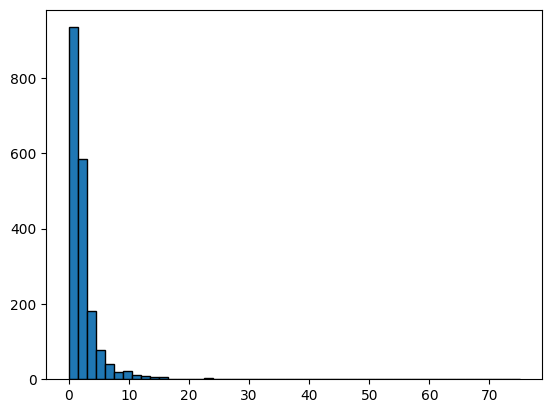

In [37]:
import matplotlib.pyplot as plt

plt.hist(cheater_df_cleaned['data_segments_1_stats_kdRatio_value'], bins=50, edgecolor='black')

In [95]:
# Drop columns where all values are the same
cheater_df_final = df_unique_columns[true_cols]

In [96]:
cheater_df_final.dropna(axis=0, inplace=True)

C:\Users\anant\AppData\Local\Temp\ipykernel_6128\1515830188.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cheater_df_final.dropna(axis=0, inplace=True)


In [98]:
cheater_df_final

,data_segments_0_stats_playstyleDefenderTrapper_value,data_segments_0_stats_matchesWon_value,data_segments_0_stats_timePlayed_value,data_segments_0_stats_defenderTeamKillsInObj_value,data_segments_0_stats_matchesAbandoned_value,data_segments_0_stats_playstyleDefenderUtilityDenier_metadata_usage_value,data_segments_0_stats_attackerRoundsWon_value,data_segments_0_stats_attackerTeamKillsInObj_value,data_segments_0_stats_matchesPlayed_value,data_segments_0_stats_playstyleAttackerRoamClearer_metadata_usage_value,...,data_segments_0_stats_deaths_value,data_segments_0_stats_playstyleDefenderIntelProvider_value,data_segments_0_stats_damageDealt_value,data_segments_0_stats_killsPerMin_value,data_segments_1_stats_kdRatio_value,data_segments_0_stats_defenderEnemyKillsInObj_value,data_segments_0_stats_attackerTeamKillsOutObj_value,data_userInfo_pageviews,data_segments_0_stats_playstyleDefenderDebuffer_value,data_segments_1_stats_killsPerMatch_value
Dict_681,359,2106,2332848,1,14,16.79,7681,3,3530,15.6,...,11707,389,212645,0.34,1.1,165,7,710,385,4.38


## Non cheater data

In [10]:
# Define the non_cheater_directory containing JSON files
non_cheater_directory = r"D:\personal projects\r6-cheater-detector\non_cheater_data"  # Change this to your actual directory

# List to store extracted data
non_data_list = []

# Loop through all files in the directory
for filename in os.listdir(non_cheater_directory):
    if filename.endswith(".json") or filename.endswith(".html"):  # Ensure it's a JSON-like file
        file_path = os.path.join(non_cheater_directory, filename)

        try:
            with open(file_path, 'r', encoding='utf-8') as file:
                content = file.read().strip()
                
                # Use BeautifulSoup to extract JSON from HTML
                soup = BeautifulSoup(content, "html.parser")
                pre_tag = soup.find("pre")
                
                if not pre_tag or not pre_tag.text:
                    print(f"Skipping invalid file: {filename}")
                    continue
                
                json_data = json.loads(pre_tag.text)
                
                # Flatten the JSON dynamically
                flattened_data = parse_json(json_data)
                non_data_list.append(flattened_data)
        
        except json.JSONDecodeError as e:
            print(f"JSON Decode Error in {filename}: {e}")
        except Exception as e:
            print(f"Unexpected Error in {filename}: {e}")

# Convert to Pandas DataFrame
non_cheater_df = pd.DataFrame(non_data_list)

Unexpected Error in 1111.json: 'data'
Unexpected Error in 2222.json: 'data'
Unexpected Error in a6zo.json: 'data'
Unexpected Error in ABXSER.json: 'data'
Unexpected Error in Ace-Lion-Taha.json: 'data'
Unexpected Error in acesaronnohiu.json: 'data'
Unexpected Error in Acheteur_de_Tn.json: 'data'
Unexpected Error in Adler24166.json: 'data'
Unexpected Error in Adrian.json: 'data'
Unexpected Error in AH1-.json: 'data'
Unexpected Error in aimhm.json: 'data'
Unexpected Error in akpdahdkbkdqhod.json: 'data'
Unexpected Error in AkusuStyle.E36.json: object of type 'NoneType' has no len()
Unexpected Error in Albedo141.T1.json: 'data'
Unexpected Error in ALEX-_-SAGAS.json: 'data'
Unexpected Error in allanime.to.json: 'data'
Unexpected Error in almstlen.json: 'data'
Unexpected Error in Alpha.SLV.json: object of type 'NoneType' has no len()
Unexpected Error in Anguishings.json: 'data'
Unexpected Error in Aqua.ZT.json: 'data'
Unexpected Error in astro.W7M.json: 'data'
Unexpected Error in ATKFresa.js

In [11]:
non_cheater_df

,platformUserId,isVerified,pageviews,xpTier,isSuspicious,nameChanges,currentSeason,clearanceLevel,isOverwolfAppUser,battlepassLevel,...,season_20_newcomer_mmr,season_20_newcomer_maxMmr,season_19_newcomer_matchesplayed,season_19_newcomer_matcheswon,season_19_newcomer_matcheslost,season_19_newcomer_kills,season_19_newcomer_deaths,season_19_newcomer_kdRatio,season_19_newcomer_mmr,season_19_newcomer_maxMmr
0,4454aa8d-a21e-4812-9ee6-15642aebf961,False,3472,NaN,None,5,35,257,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,f3389d54-511d-4cf0-89e8-1eca45d2e57f,True,1100,NaN,None,2,34,170,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6d82f330-3d7d-403f-977f-769c0e9cadf8,False,290,NaN,None,1,34,69,False,56.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,741a9538-77e4-45ab-9d3d-59aac9c554ea,False,962,NaN,None,2,35,230,True,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,aaf7d5f5-bd70-49be-b6b5-bdd34b112a35,False,693,NaN,None,5,34,343,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1299,271eb21e-e7d1-4090-b213-431855b34eef,False,779,NaN,None,1,34,399,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1300,d5b93f42-68fd-4704-83f7-3445bc3ac102,False,101,NaN,None,0,35,90,True,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1301,36aaa514-c5c7-4b09-8e36-94d6be8f3982,False,833,NaN,None,1,35,433,True,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1302,bb3a30d6-1b6d-4aec-9802-4152cf3d1a20,False,52,NaN,None,0,35,235,False,NaN,...,3507.0,NaN,12.0,6.0,3.0,30.0,13.0,2.307692,3072.0,NaN


In [12]:
cheater_df["is_cheater"] = 1  # Label cheaters as 1
non_cheater_df["is_cheater"] = 0  # Label non-cheaters as 0

In [13]:
import pandas as pd

dataset = pd.concat([cheater_df, non_cheater_df], axis=0, ignore_index=True)


In [14]:
dataset

,platformUserId,isVerified,pageviews,xpTier,isSuspicious,nameChanges,currentSeason,clearanceLevel,isOverwolfAppUser,battlepassLevel,...,gamemode_event_winpercentage,season_19_newcomer_matchesplayed,season_19_newcomer_matcheswon,season_19_newcomer_matcheslost,season_19_newcomer_kills,season_19_newcomer_deaths,season_19_newcomer_kdRatio,season_19_newcomer_mmr,season_19_newcomer_maxMmr,is_cheater
0,bea4b579-77a8-4618-964e-9ca6f97b9889,False,0,NaN,None,1,34,25.0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,3d0c4c2d-889d-4a8c-a7cb-c443a4384322,False,0,NaN,None,0,34,135.0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
2,a3f91a93-a79f-4280-ae9e-20ab5fb07253,False,273,NaN,None,1,34,68.0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
3,740afdbf-82eb-43f7-b670-f177102cc86e,False,0,NaN,None,0,34,42.0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,62299f22-65d5-4e7f-a403-f8eb937612e8,False,6552,NaN,None,0,34,83.0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3199,271eb21e-e7d1-4090-b213-431855b34eef,False,779,NaN,None,1,34,399.0,False,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3200,d5b93f42-68fd-4704-83f7-3445bc3ac102,False,101,NaN,None,0,35,90.0,True,NaN,...,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3201,36aaa514-c5c7-4b09-8e36-94d6be8f3982,False,833,NaN,None,1,35,433.0,True,NaN,...,50.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3202,bb3a30d6-1b6d-4aec-9802-4152cf3d1a20,False,52,NaN,None,0,35,235.0,False,NaN,...,66.67,12.0,6.0,3.0,30.0,13.0,2.307692,3072.0,NaN,0


In [15]:
dataset.to_csv('dataset.csv')

In [17]:
for col in dataset.columns:
    print(col)

platformUserId
isVerified
pageviews
xpTier
isSuspicious
nameChanges
currentSeason
clearanceLevel
isOverwolfAppUser
battlepassLevel
season_1_quickmatch_matchesplayed
season_1_quickmatch_matcheswon
season_1_quickmatch_matcheslost
season_1_quickmatch_kills
season_1_quickmatch_deaths
season_1_quickmatch_kdRatio
season_1_quickmatch_mmr
season_1_quickmatch_maxMmr
season_1_ranked_matchesplayed
season_1_ranked_matcheswon
season_1_ranked_matcheslost
season_1_ranked_kills
season_1_ranked_deaths
season_1_ranked_kdRatio
season_1_ranked_mmr
season_1_ranked_maxMmr
season_1_standard_matchesplayed
season_1_standard_matcheswon
season_1_standard_matcheslost
season_1_standard_kills
season_1_standard_deaths
season_1_standard_kdRatio
season_1_standard_mmr
season_1_standard_maxMmr
season_1_event_matchesplayed
season_1_event_matcheswon
season_1_event_matcheslost
season_1_event_kills
season_1_event_deaths
season_1_event_kdRatio
season_1_event_mmr
season_1_event_maxMmr
season_1_arcade_matchesplayed
season_1_ar

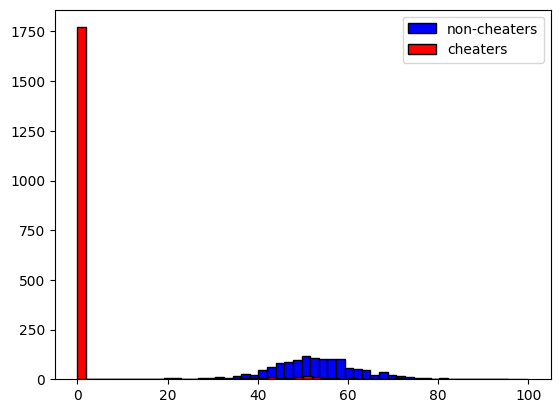

In [18]:
fig, ax =plt.subplots()

cheater_headshots_df = dataset[dataset['is_cheater']==1]
cheater_headshots = cheater_headshots_df['overview_headshotpercentage']

non_cheater_headshots_df = dataset[dataset['is_cheater']==0]
non_cheater_headshots = non_cheater_headshots_df['overview_headshotpercentage']


ax.hist(non_cheater_headshots,edgecolor='black', bins=50, color='blue', label='non-cheaters')
ax.hist(cheater_headshots,edgecolor='black', bins=50, color='red', label='cheaters')

plt.legend()
plt.show()

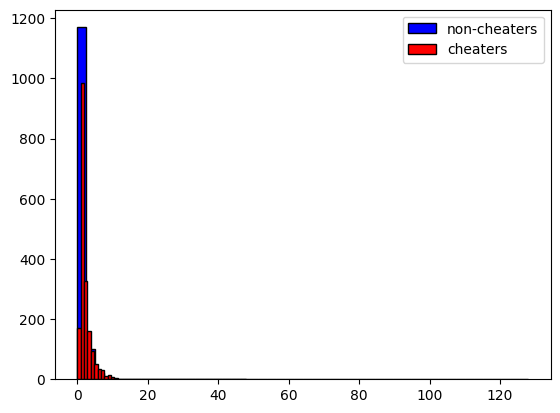

In [19]:
fig, ax =plt.subplots()

cheater_headshots_df = dataset[dataset['is_cheater']==1]
cheater_headshots = cheater_headshots_df['overview_kdratio']

non_cheater_headshots_df = dataset[dataset['is_cheater']==0]
non_cheater_headshots = non_cheater_headshots_df['overview_kdratio']


ax.hist(non_cheater_headshots,edgecolor='black', bins=50, color='blue', label='non-cheaters')
ax.hist(cheater_headshots,edgecolor='black', bins=50, color='red', label='cheaters')

plt.legend()
plt.show()

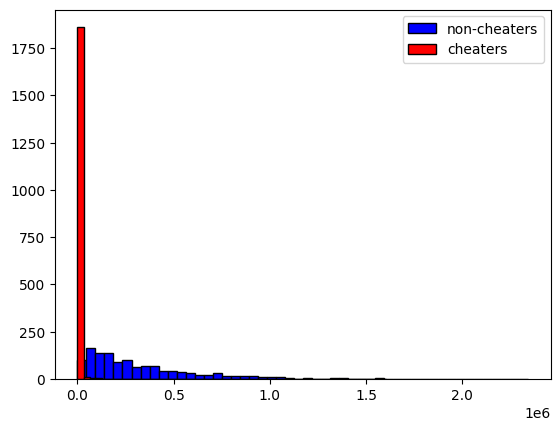

In [20]:
fig, ax =plt.subplots()

cheater_headshots_df = dataset[dataset['is_cheater']==1]
cheater_headshots = cheater_headshots_df['overview_damagedealt']

non_cheater_headshots_df = dataset[dataset['is_cheater']==0]
non_cheater_headshots = non_cheater_headshots_df['overview_damagedealt']


ax.hist(non_cheater_headshots,edgecolor='black', bins=50, color='blue', label='non-cheaters')
ax.hist(cheater_headshots,edgecolor='black', bins=50, color='red', label='cheaters')

plt.legend()
plt.show()

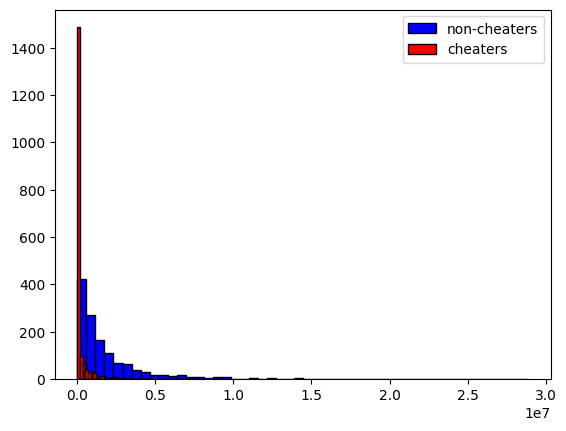

In [21]:
fig, ax =plt.subplots()

cheater_headshots_df = dataset[dataset['is_cheater']==1]
cheater_headshots = cheater_headshots_df['overview_timeplayed']

non_cheater_headshots_df = dataset[dataset['is_cheater']==0]
non_cheater_headshots = non_cheater_headshots_df['overview_timeplayed']


ax.hist(non_cheater_headshots,edgecolor='black', bins=50, color='blue', label='non-cheaters')
ax.hist(cheater_headshots,edgecolor='black', bins=50, color='red', label='cheaters')

plt.legend()
plt.show()

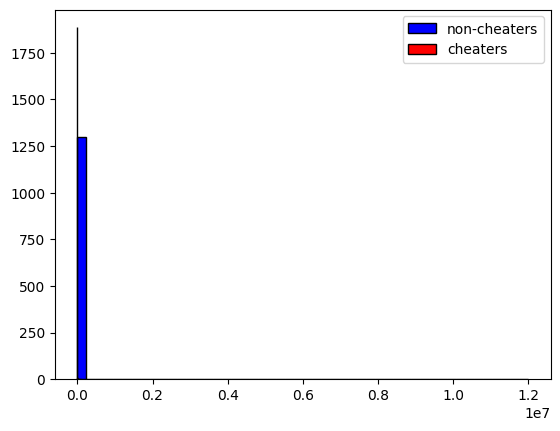

In [22]:
fig, ax =plt.subplots()

cheater_headshots_df = dataset[dataset['is_cheater']==1]
cheater_headshots = cheater_headshots_df['overview_timealive']

non_cheater_headshots_df = dataset[dataset['is_cheater']==0]
non_cheater_headshots = non_cheater_headshots_df['overview_timealive']


ax.hist(non_cheater_headshots,edgecolor='black', bins=50, color='blue', label='non-cheaters')
ax.hist(cheater_headshots,edgecolor='black', bins=50, color='red', label='cheaters')

plt.legend()
plt.show()

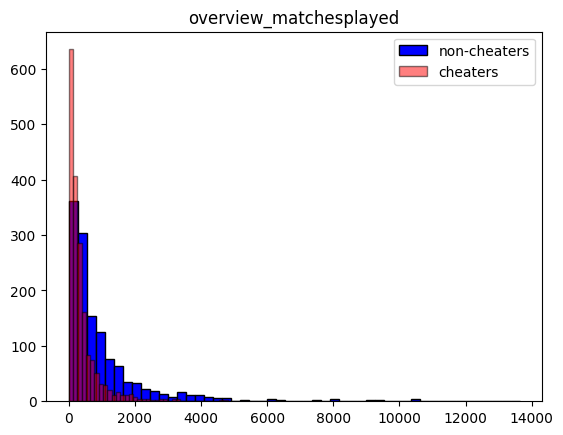

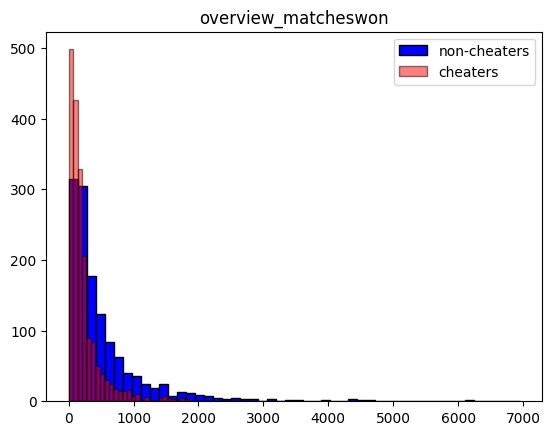

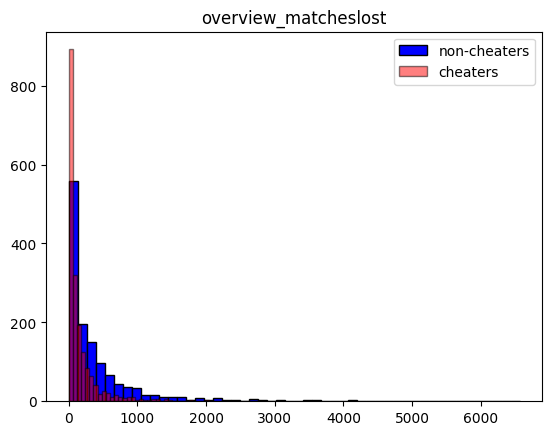

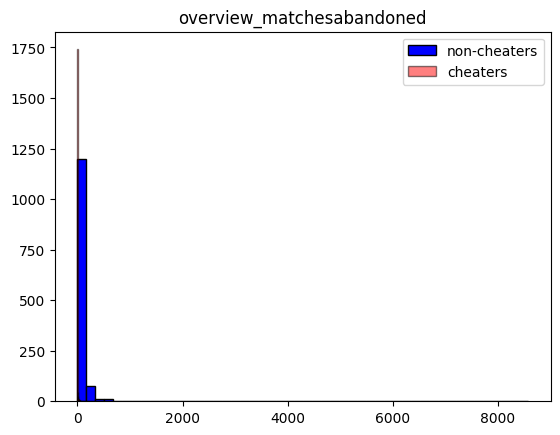

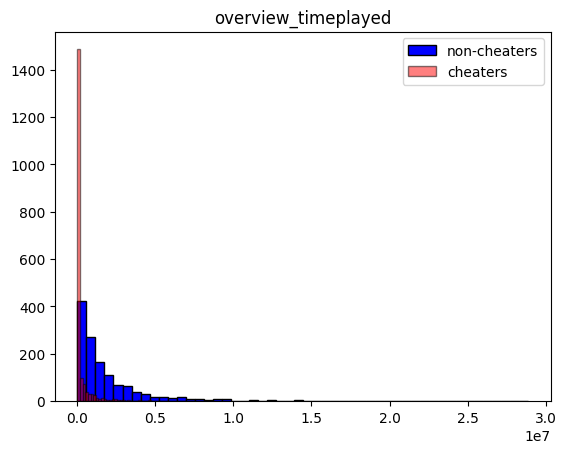

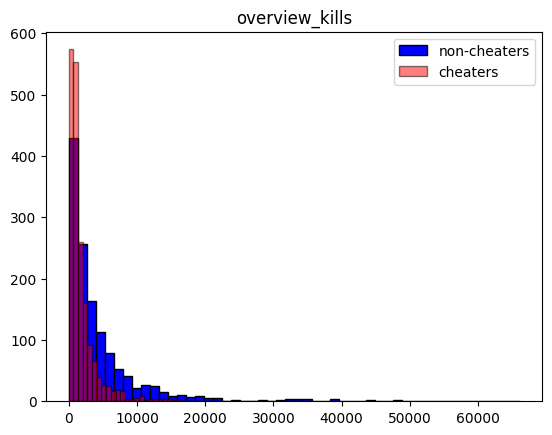

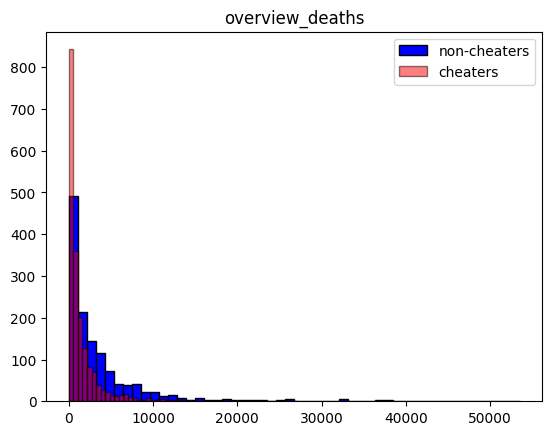

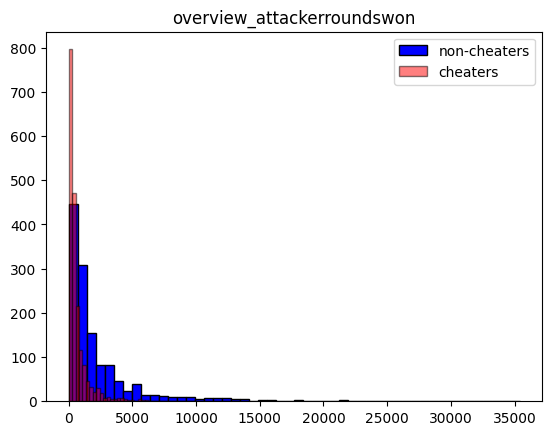

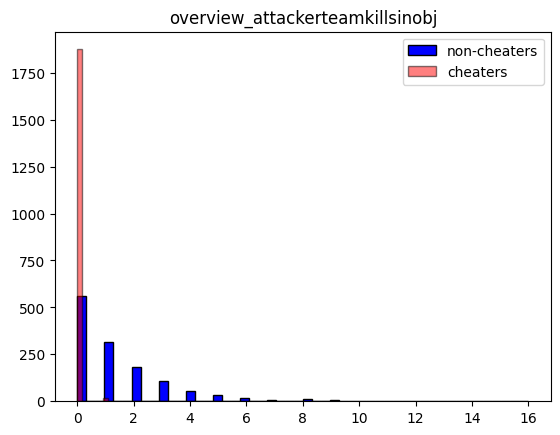

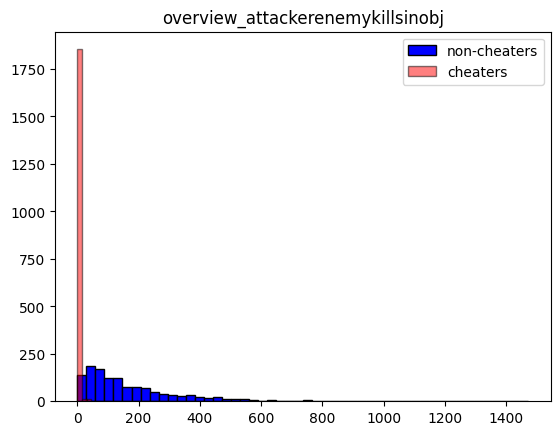

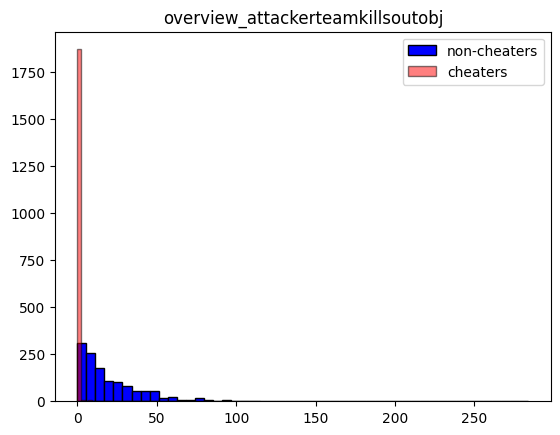

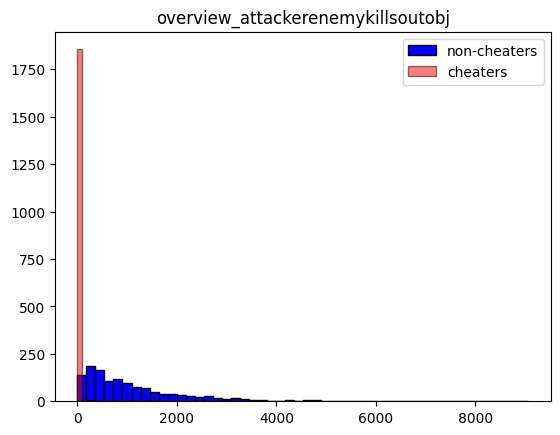

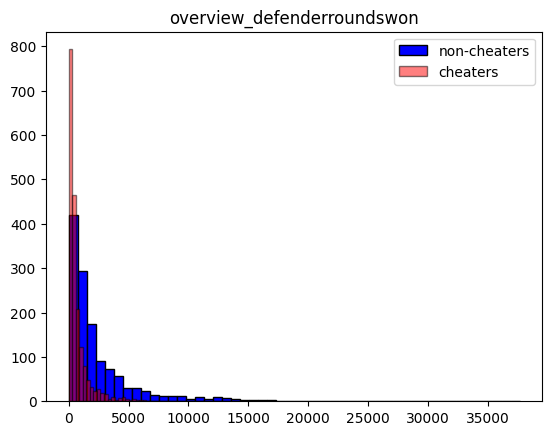

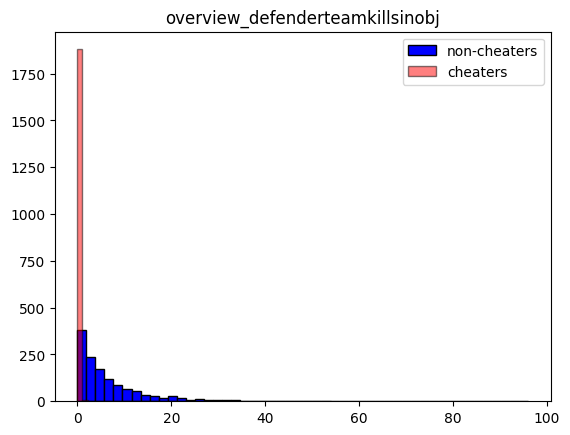

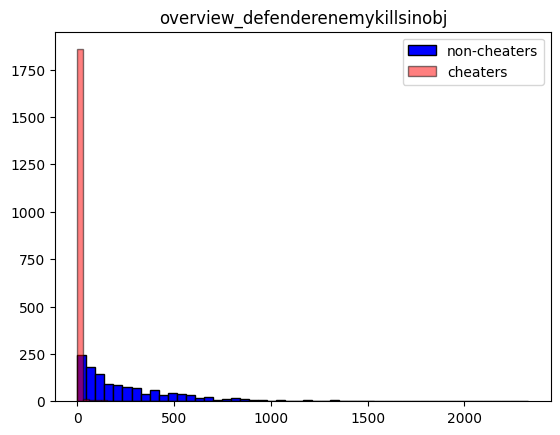

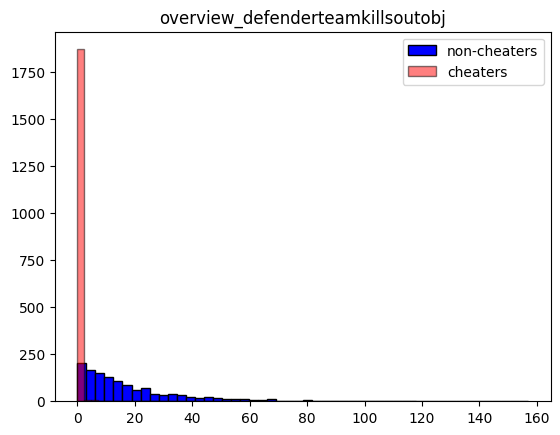

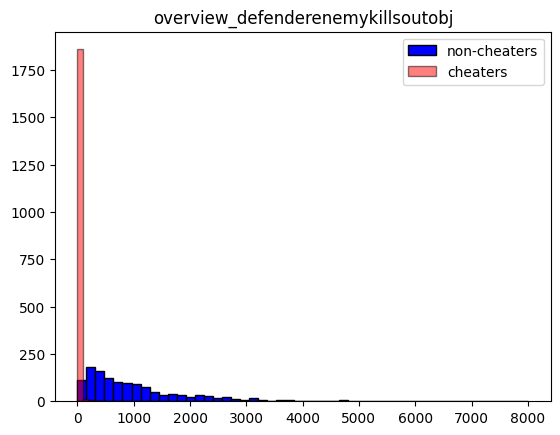

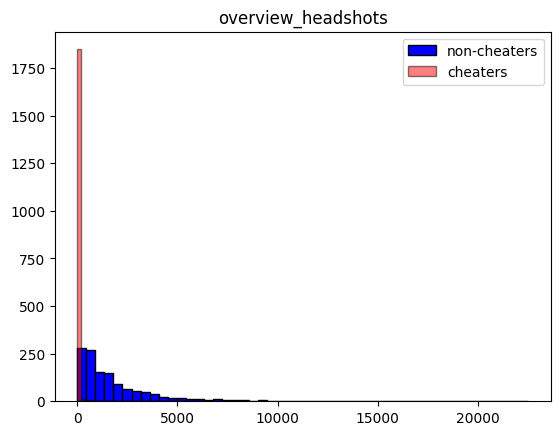

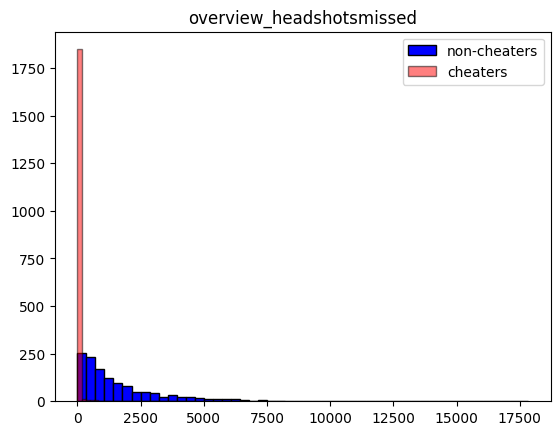

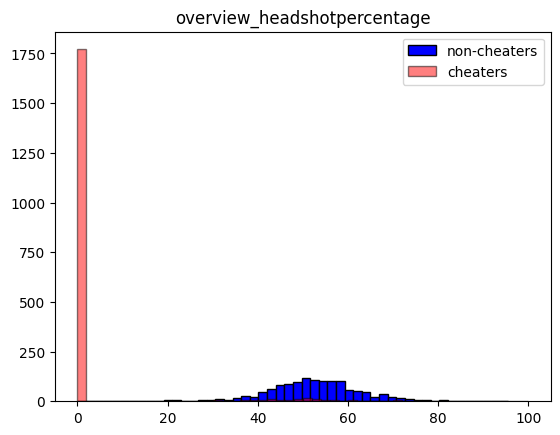

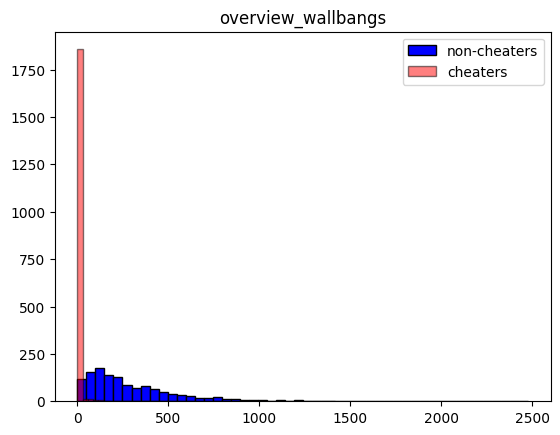

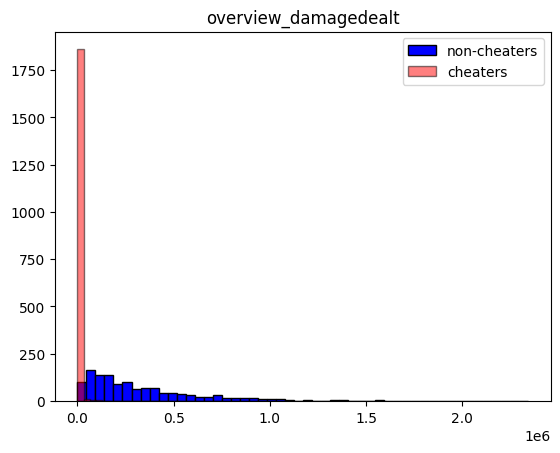

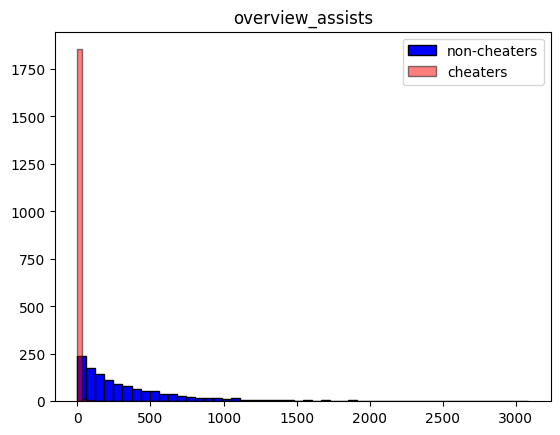

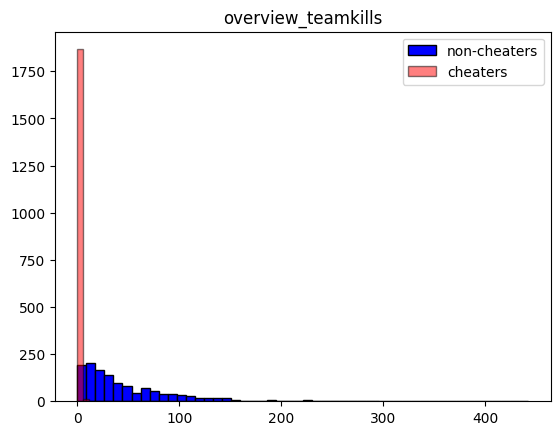

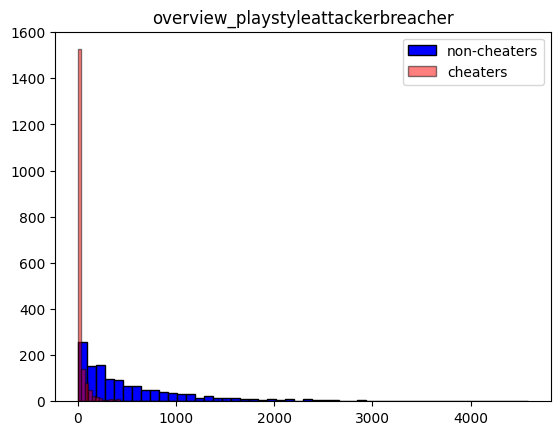

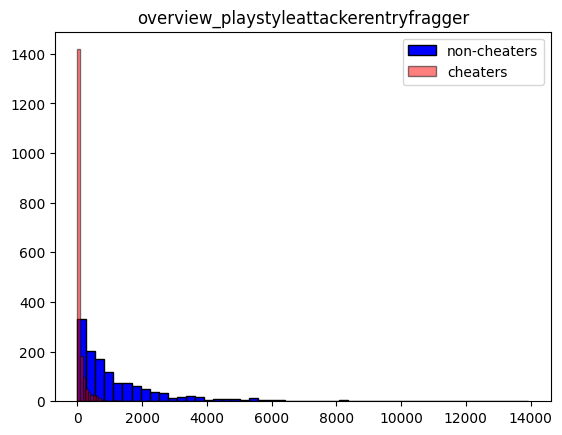

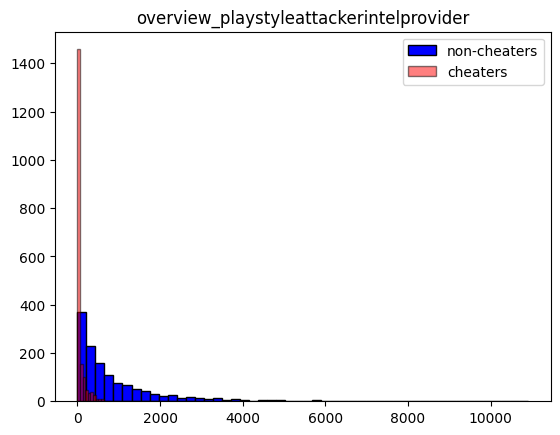

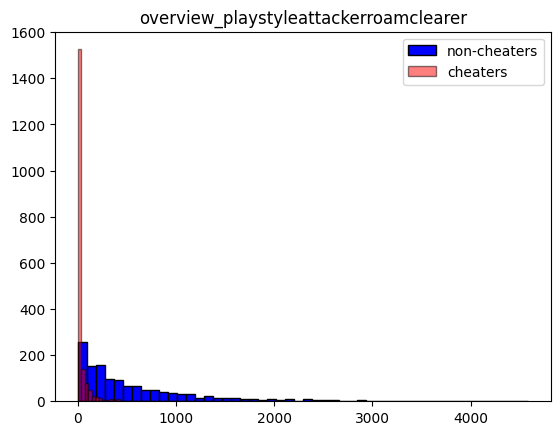

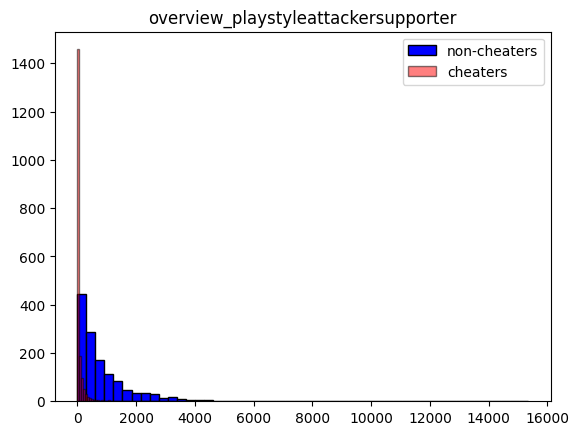

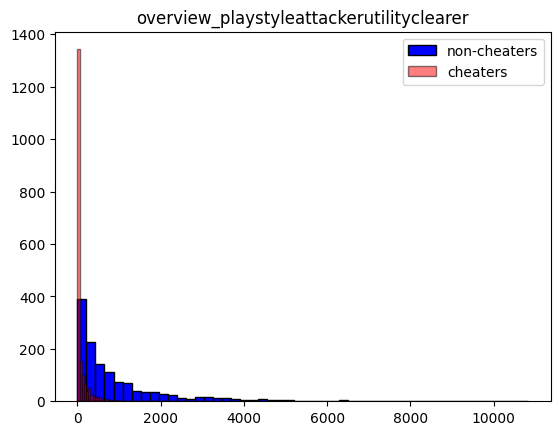

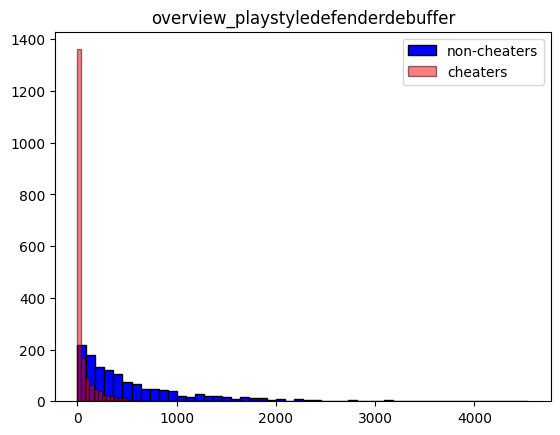

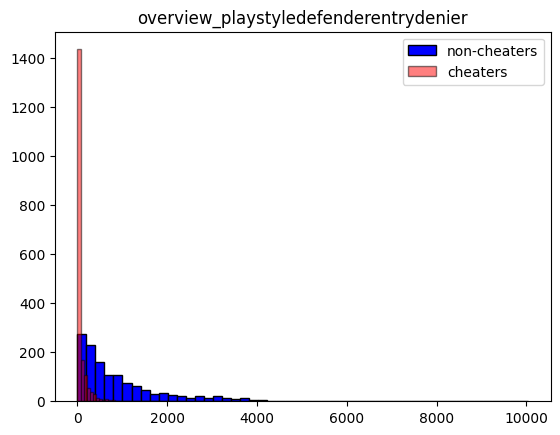

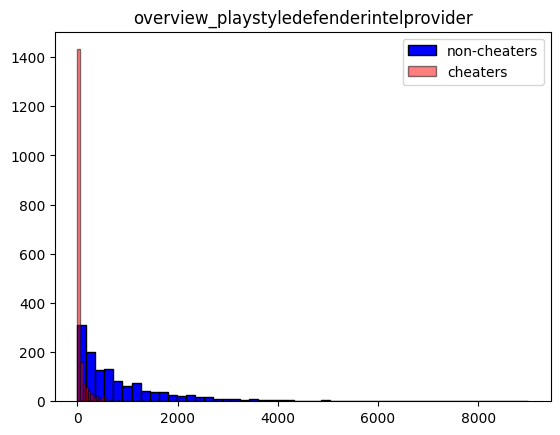

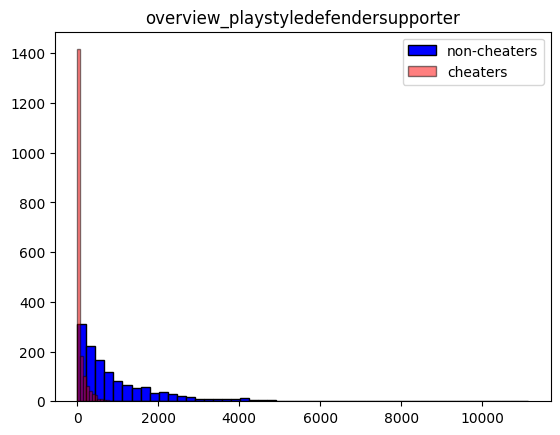

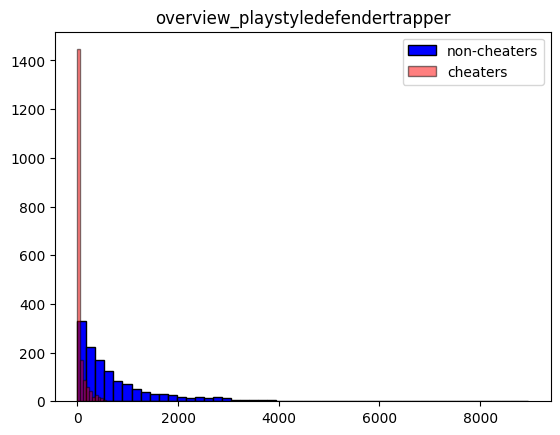

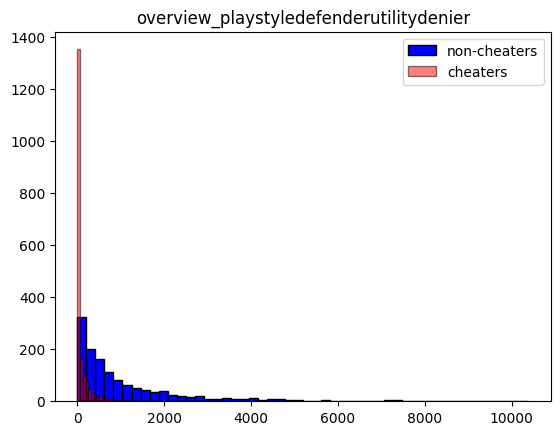

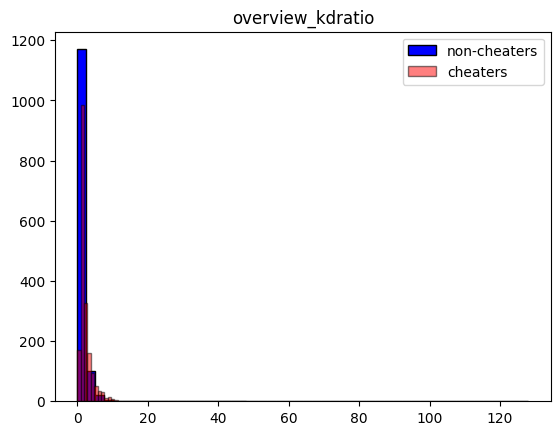

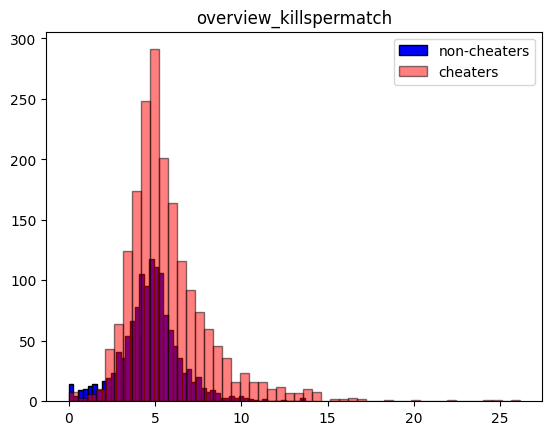

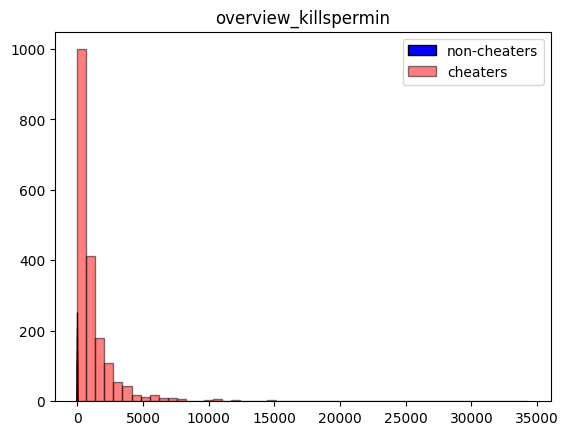

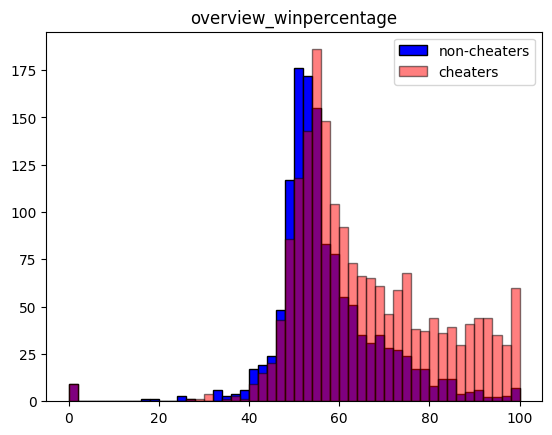

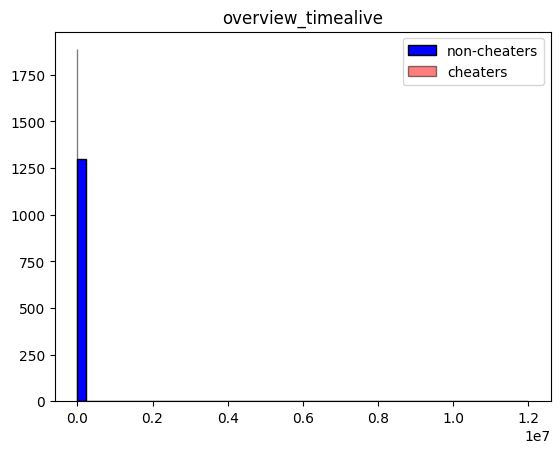

In [26]:
for col in dataset.columns:
    if 'overview' in col:
        cheater_headshots_df = dataset[dataset['is_cheater']==1]
        cheater_headshots = cheater_headshots_df[col]

        non_cheater_headshots_df = dataset[dataset['is_cheater']==0]
        non_cheater_headshots = non_cheater_headshots_df[col]


        plt.hist(non_cheater_headshots,edgecolor='black', bins=50, color='blue', label='non-cheaters')
        plt.hist(cheater_headshots,edgecolor='black', bins=50, color='red', label='cheaters', alpha=0.5)
        plt.title(f'{col}')
        plt.legend()
        plt.show()

In [ ]:
# Store feature names before adding missing indicators (for alignment)
original_features = dataset.columns.tolist()

# Add missing indicators
for col in original_features:
    dataset[col + "_missing"] = dataset[col].isna().astype(int)  # 1 if missing, 0 if present


In [69]:
# Identify boolean columns
bool_cols = dataset.select_dtypes(include=['bool']).columns

# Convert them to integers (True → 1, False → 0)
dataset[bool_cols] = dataset[bool_cols].astype(int)


In [70]:
dataset

,platformUserId,isVerified,pageviews,xpTier,isSuspicious,nameChanges,currentSeason,clearanceLevel,isOverwolfAppUser,battlepassLevel,...,gamemode_event_winpercentage_missing,season_19_newcomer_matchesplayed_missing,season_19_newcomer_matcheswon_missing,season_19_newcomer_matcheslost_missing,season_19_newcomer_kills_missing,season_19_newcomer_deaths_missing,season_19_newcomer_kdRatio_missing,season_19_newcomer_mmr_missing,season_19_newcomer_maxMmr_missing,is_cheater_missing
0,bea4b579-77a8-4618-964e-9ca6f97b9889,0,0,NaN,None,1,34,25.0,0,NaN,...,1,1,1,1,1,1,1,1,1,0
1,3d0c4c2d-889d-4a8c-a7cb-c443a4384322,0,0,NaN,None,0,34,135.0,0,NaN,...,1,1,1,1,1,1,1,1,1,0
2,a3f91a93-a79f-4280-ae9e-20ab5fb07253,0,273,NaN,None,1,34,68.0,0,NaN,...,1,1,1,1,1,1,1,1,1,0
3,740afdbf-82eb-43f7-b670-f177102cc86e,0,0,NaN,None,0,34,42.0,0,NaN,...,1,1,1,1,1,1,1,1,1,0
4,62299f22-65d5-4e7f-a403-f8eb937612e8,0,6552,NaN,None,0,34,83.0,0,NaN,...,1,1,1,1,1,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3199,271eb21e-e7d1-4090-b213-431855b34eef,0,779,NaN,None,1,34,399.0,0,NaN,...,1,1,1,1,1,1,1,1,1,0
3200,d5b93f42-68fd-4704-83f7-3445bc3ac102,0,101,NaN,None,0,35,90.0,1,NaN,...,0,1,1,1,1,1,1,1,1,0
3201,36aaa514-c5c7-4b09-8e36-94d6be8f3982,0,833,NaN,None,1,35,433.0,1,NaN,...,0,1,1,1,1,1,1,1,1,0
3202,bb3a30d6-1b6d-4aec-9802-4152cf3d1a20,0,52,NaN,None,0,35,235.0,0,NaN,...,0,0,0,0,0,0,0,0,1,0


In [71]:
dataset.drop(['platformUserId', 'is_cheater_missing', 'isSuspicious', 'xpTier'], inplace=True, axis=1)

In [72]:
dataset

,isVerified,pageviews,nameChanges,currentSeason,clearanceLevel,isOverwolfAppUser,battlepassLevel,season_1_quickmatch_matchesplayed,season_1_quickmatch_matcheswon,season_1_quickmatch_matcheslost,...,gamemode_event_killspermatch_missing,gamemode_event_winpercentage_missing,season_19_newcomer_matchesplayed_missing,season_19_newcomer_matcheswon_missing,season_19_newcomer_matcheslost_missing,season_19_newcomer_kills_missing,season_19_newcomer_deaths_missing,season_19_newcomer_kdRatio_missing,season_19_newcomer_mmr_missing,season_19_newcomer_maxMmr_missing
0,0,0,1,34,25.0,0,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
1,0,0,0,34,135.0,0,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
2,0,273,1,34,68.0,0,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
3,0,0,0,34,42.0,0,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
4,0,6552,0,34,83.0,0,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3199,0,779,1,34,399.0,0,NaN,NaN,NaN,NaN,...,1,1,1,1,1,1,1,1,1,1
3200,0,101,0,35,90.0,1,NaN,NaN,NaN,NaN,...,0,0,1,1,1,1,1,1,1,1
3201,0,833,1,35,433.0,1,NaN,NaN,NaN,NaN,...,0,0,1,1,1,1,1,1,1,1
3202,0,52,0,35,235.0,0,NaN,NaN,NaN,NaN,...,0,0,0,0,0,0,0,0,0,1


In [73]:
object_cols = dataset.select_dtypes(include=['object']).columns
print("Object Columns:", object_cols)


Object Columns: Index([], dtype='object')


In [75]:
import joblib
dataset2 = dataset.copy()
dataset2.drop('is_cheater', axis=1, inplace=True)

In [76]:
# Save feature names (including missing indicators)
joblib.dump(dataset2.columns, "feature_names.pkl")

['feature_names.pkl']

In [60]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder


# Separate features and target
X = dataset.drop(columns=["is_cheater"])  # Features
y = dataset["is_cheater"]  # Target variable

# Handle categorical features (if any beyond True/False encoding)
X = pd.get_dummies(X)  # One-hot encode categorical variables if needed

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize XGBoost classifier
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Get feature importance scores
feature_importance = model.get_booster().get_score(importance_type="gain")

# Convert to DataFrame
importance_df = pd.DataFrame(feature_importance.items(), columns=["Feature", "Importance"])

# Sort by importance
importance_df = importance_df.sort_values(by="Importance", ascending=False)

# Get top 10 features
top_10_features = importance_df.head(10)


# Return top 10 feature names
top_10_features["Feature"].tolist()


d:\personal projects\r6-cheater-detector\venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [03:50:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


['overview_damagedealt',
 'overview_wallbangs',
 'season_20_quickmatch_matchesplayed',
 'season_22_ranked_kdRatio',
 'season_29_ranked_kdRatio',
 'gamemode_arcade_kills',
 'season_24_ranked_kdRatio',
 'season_20_ranked_kdRatio',
 'overview_defenderenemykillsoutobj',
 'season_17_ranked_matcheswon']

In [61]:
# Predict on X_test
y_pred = model.predict(X_test)

# Convert predictions into DataFrame for display
predictions_df = pd.DataFrame({"Actual": y_test, "Predicted": y_pred})

In [62]:
predictions_df

,Actual,Predicted
610,1,1
3047,0,0
2724,0,0
1913,0,0
2882,0,0
...,...,...
2229,0,0
1025,1,1
1029,1,1
1926,0,0


In [63]:
model.save_model('xgb_100.json')